In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("netflix_titles.csv")

In [4]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [6]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [21]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [22]:
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

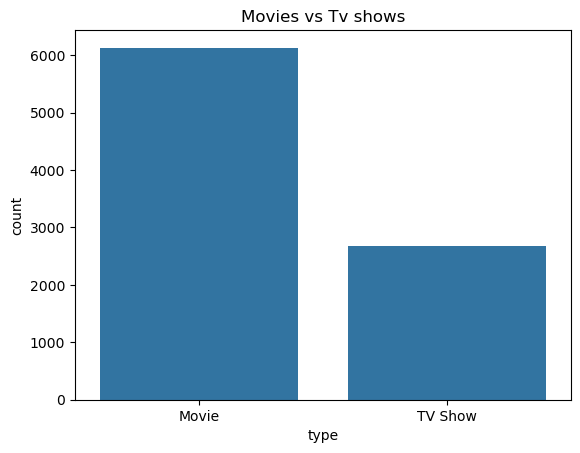

In [23]:
sns.countplot(x='type',data=df)    #Univariate analysis 
plt.title("Movies vs Tv shows")
plt.show()

### Insight
The analysis shows that Movies dominate Netflix content compared to TV Shows. This suggests that Netflix focuses more on standalone entertainment content with higher content volume.

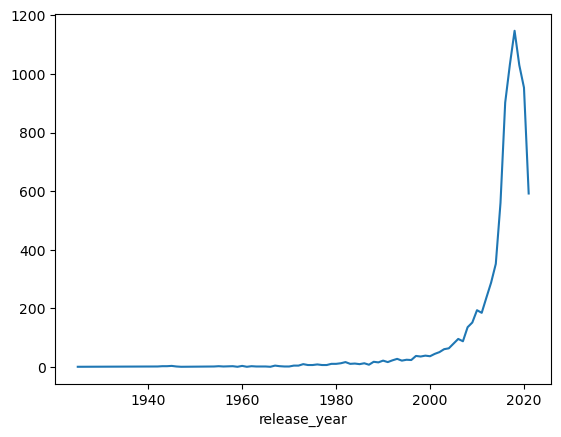

In [24]:
df['release_year'].value_counts().sort_index().plot()
plt.show()

In [25]:
df['rating'].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

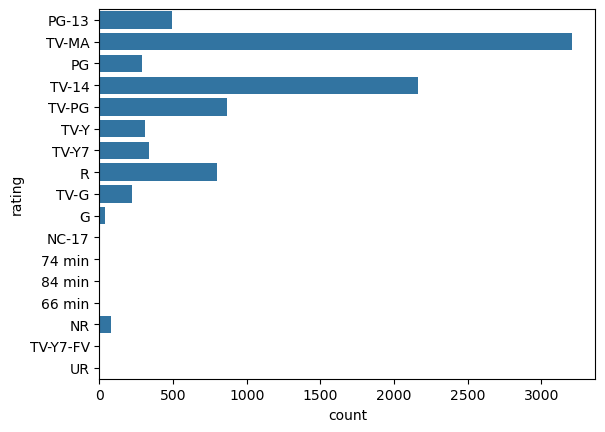

In [26]:
sns.countplot(y='rating',data=df) #Too many values of rating category so we used y=rating for better readability
plt.show()

In [27]:
df['country'].value_counts().head(10)

country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

In [28]:
df['listed_in'].value_counts().head(10)

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            220
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Name: count, dtype: int64

In [30]:
df['date_added'] = df['date_added'].str.strip()

In [31]:
df['date_added'] = pd.to_datetime(df['date_added'])

In [32]:
df['date_added'].dtype

dtype('<M8[ns]')

In [ ]:
df['date_added'].value_counts().sort_index()


In [34]:
df['year_added']=df['date_added'].dt.year

In [40]:
df[['date_added','year_added']].head()

,date_added,year_added
0,2021-09-25,2021.0
1,2021-09-24,2021.0
2,2021-09-24,2021.0
3,2021-09-24,2021.0
4,2021-09-24,2021.0


In [46]:
yearly_additions=df['year_added'].value_counts().sort_index()
yearly_additions

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
Name: count, dtype: int64

Text(0, 0.5, 'Number of titles added')

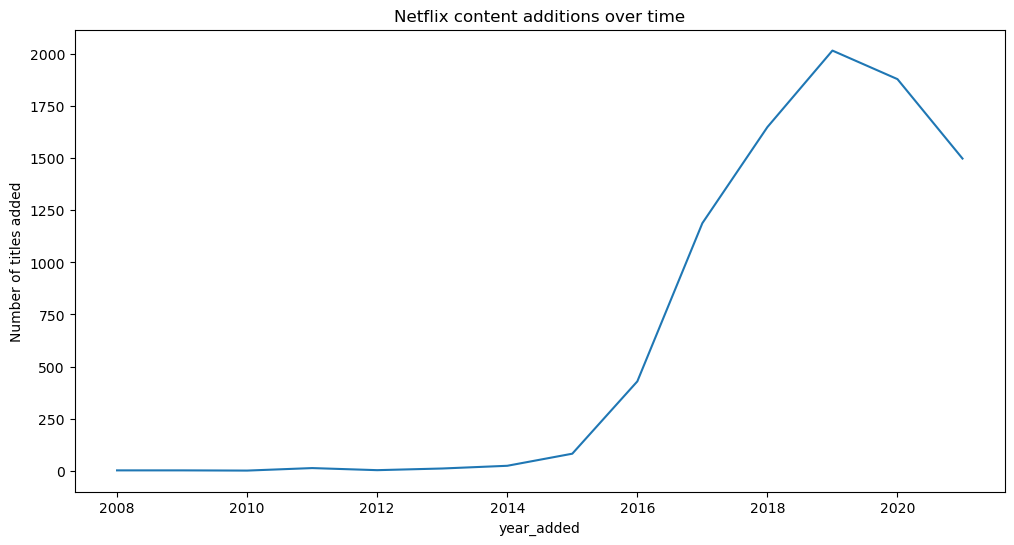

In [51]:
plt.figure(figsize=(12,6))
yearly_additions.plot()
plt.title("Netflix content additions over time")
plt.ylabel("Number of titles added")

In [52]:
df.duplicated().sum()

np.int64(0)

In [53]:
movies=df[df['type']=='Movie'].copy()  #filtered data to only movues 

In [54]:
movies['duration'].head()

0      90 min
6      91 min
7     125 min
9     104 min
12    127 min
Name: duration, dtype: object

In [55]:
movies['duration'] = movies['duration'].str.replace(' min', '')

In [56]:
movies['duration'].isnull().sum()

np.int64(3)

### missing values handling

In [57]:
movies=movies.dropna(subset=['duration'])

In [58]:
movies['duration'].isnull().sum()

np.int64(0)

In [59]:
movies['duration'] = movies['duration'].astype(int)

In [60]:
movies['duration'].head()

0      90
6      91
7     125
9     104
12    127
Name: duration, dtype: int64

In [61]:
movies['duration'].describe()

count    6128.000000
mean       99.577187
std        28.290593
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration, dtype: float64

In [62]:
plt.figure(figsize=(10,6))


<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

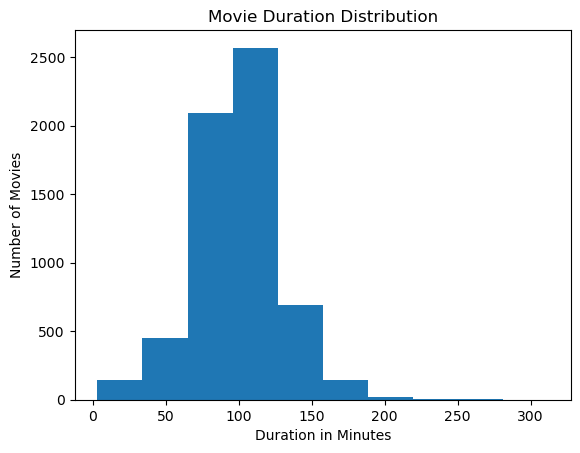

In [63]:
plt.title("Movie Duration Distribution")
plt.xlabel("Duration in Minutes")
plt.ylabel("Number of Movies")
plt.hist(movies['duration'])
plt.show()

In [64]:
movies[['release_year','duration']].corr()

,release_year,duration
release_year,1.000000,-0.206285
duration,-0.206285,1.000000


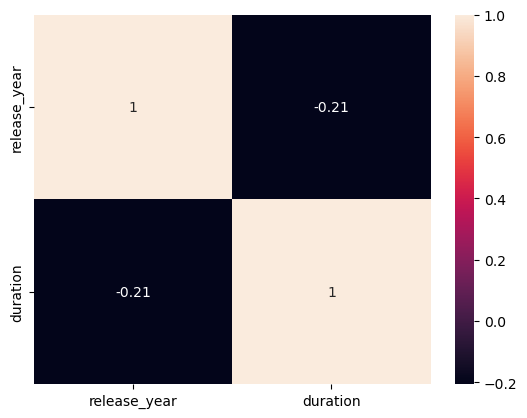

In [65]:
sns.heatmap(movies[['release_year','duration']].corr(),annot=True)
plt.show()

In [66]:
top_genres=df['listed_in'].value_counts().head(10)

Text(0, 0.5, 'Movies')

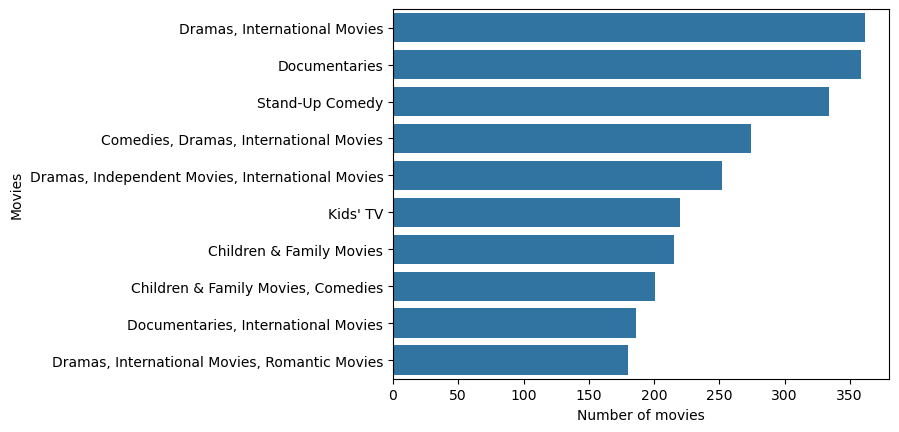

In [67]:
sns.barplot(x=top_genres.values,y=top_genres.index)
plt.xlabel("Number of movies")
plt.ylabel("Movies")

# Conclusion

From this Exploratory Data Analysis on the Netflix dataset, several important trends and patterns were identified.

The analysis showed that Movies dominate Netflix content compared to TV Shows. Netflix content additions increased significantly after 2015, indicating rapid platform expansion and increased content acquisition.

The ratings analysis suggested that mature audience categories such as TV-MA and TV-14 are highly common on the platform. Country-wise analysis revealed that the United States contributes the largest amount of content to Netflix.

Genre analysis highlighted the most dominant entertainment categories, while movie duration analysis showed that most movies follow standard feature-length runtime patterns.

Overall, this project helped in understanding the importance of data cleaning, visualization, trend analysis, and extracting meaningful insights from raw data using Exploratory Data Analysis techniques.